<a href="https://colab.research.google.com/github/fidhaashraf123/EDA/blob/main/EDA/Bangaluru_house_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset/Bengaluru_House_Data.csv')
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [ ]:
df.tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,ArsiaEx,3453,4.0,0.0,231.0
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,NaN,3600,5.0,NaN,400.0
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,Mahla T,1141,2.0,1.0,60.0
13318,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,SollyCl,4689,4.0,1.0,488.0
13319,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,NaN,550,1.0,1.0,17.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [ ]:
df.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
society,5502
total_sqft,0
bath,73
balcony,609
price,0


In [ ]:
df.drop('society',axis=1,inplace=True)

In [ ]:
df.drop('balcony',axis=1,inplace=True)

In [ ]:
df.dropna(subset=['size'],inplace=True)

<Axes: >

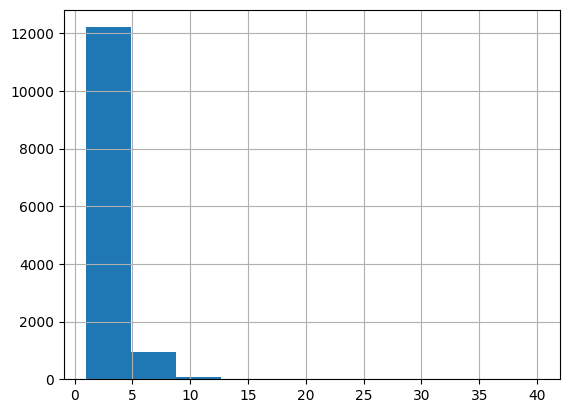

In [ ]:
df['bath'].hist()

In [ ]:
df['bath'].fillna(df['bath'].median(),inplace=True)

NameError: name 'df' is not defined

In [ ]:
df.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,0
price,0


In [ ]:
print(df['area_type'].unique())

['Super built-up  Area' 'Plot  Area' 'Built-up  Area' 'Carpet  Area']


In [ ]:
print(df['size'].unique())

['2 BHK' '4 Bedroom' '3 BHK' '4 BHK' '6 Bedroom' '3 Bedroom' '1 BHK'
 '1 RK' '1 Bedroom' '8 Bedroom' '2 Bedroom' '7 Bedroom' '5 BHK' '7 BHK'
 '6 BHK' '5 Bedroom' '11 BHK' '9 BHK' '9 Bedroom' '27 BHK' '10 Bedroom'
 '11 Bedroom' '10 BHK' '19 BHK' '16 BHK' '43 Bedroom' '14 BHK' '8 BHK'
 '12 Bedroom' '13 BHK' '18 Bedroom']


In [ ]:
df.duplicated().sum()

np.int64(668)

In [ ]:
df.shape

(13303, 7)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(12635, 7)

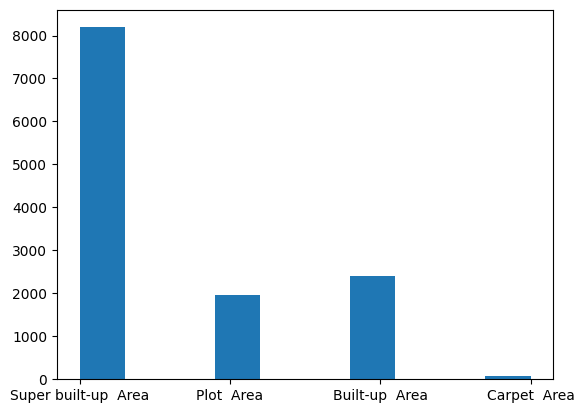

In [ ]:
plt.hist(df['area_type'])
plt.show()

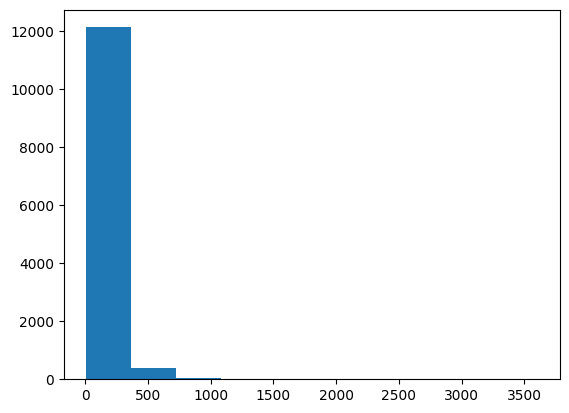

In [ ]:
plt.hist(df['price'])
plt.show()

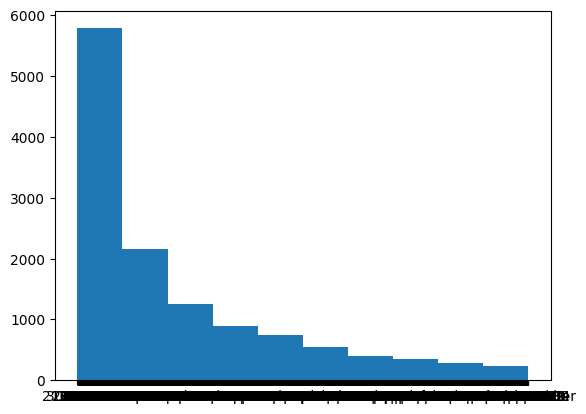

In [ ]:
plt.hist(df['total_sqft'])
plt.show()

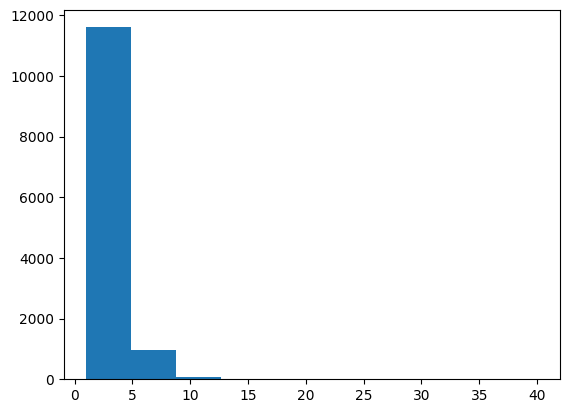

In [ ]:

plt.hist(df['bath'])
plt.show()

In [ ]:
df

,area_type,availability,location,size,total_sqft,bath,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,51.00
...,...,...,...,...,...,...,...
13314,Super built-up Area,Ready To Move,Green Glen Layout,3 BHK,1715,3.0,112.00
13315,Built-up Area,Ready To Move,Whitefield,5 Bedroom,3453,4.0,231.00
13316,Super built-up Area,Ready To Move,Richards Town,4 BHK,3600,5.0,400.00
13317,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,1141,2.0,60.00


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['area_type']=le.fit_transform(df['area_type'])
df['location']=le.fit_transform(df['location'])

In [ ]:
def split_features(value):
  if 'BHK' in value:

    bedroom=int(value.split()[0])
    hall=1
    kitchen=1
  elif 'Bedroom' in value:


    bedroom=int(value.split()[0])
    hall=0
    kitchen=0
  elif value =='1 RK':
    bedroom=1
    hall=0
    kitchen=0
  else:
    bedroom=None
    hall=None
    kitchen=None
  return bedroom,hall,kitchen

df[['Bedroom','Hall','Kitchen']]=df['size'].apply(lambda x:pd.Series(split_features(x)))

df

,area_type,availability,location,size,total_sqft,bath,price,Bedroom,Hall,Kitchen
0,3,19-Dec,419,2 BHK,1056,2.0,39.07,2,1,1
1,2,Ready To Move,317,4 Bedroom,2600,5.0,120.00,4,0,0
2,0,Ready To Move,1178,3 BHK,1440,2.0,62.00,3,1,1
3,3,Ready To Move,756,3 BHK,1521,3.0,95.00,3,1,1
4,3,Ready To Move,715,2 BHK,1200,2.0,51.00,2,1,1
...,...,...,...,...,...,...,...,...,...,...
13314,3,Ready To Move,474,3 BHK,1715,3.0,112.00,3,1,1
13315,0,Ready To Move,1251,5 Bedroom,3453,4.0,231.00,5,0,0
13316,3,Ready To Move,1003,4 BHK,3600,5.0,400.00,4,1,1
13317,0,Ready To Move,971,2 BHK,1141,2.0,60.00,2,1,1


In [ ]:
df.drop('size',axis=1,inplace=True)

In [ ]:
df['availability']=pd.to_datetime(df['availability'],format='%d-%b',errors='coerce')

In [ ]:
df['availability'].fillna(df['availability'].median(),inplace=True)

/tmp/ipython-input-272/1442938058.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['availability'].fillna(df['availability'].median(),inplace=True)


In [ ]:
df.isnull().sum()

,0
area_type,0
availability,0
location,0
total_sqft,0
bath,0
price,0
Bedroom,0
Hall,0
Kitchen,0


In [ ]:
df.head()

,area_type,availability,location,total_sqft,bath,price,Bedroom,Hall,Kitchen
0,3,1900-12-19,419,1056,2.0,39.07,2,1,1
1,2,1900-07-18,317,2600,5.0,120.00,4,0,0
2,0,1900-07-18,1178,1440,2.0,62.00,3,1,1
3,3,1900-07-18,756,1521,3.0,95.00,3,1,1
4,3,1900-07-18,715,1200,2.0,51.00,2,1,1


In [ ]:
df['month']=df["availability"].dt.month

In [ ]:
df['year']=df["availability"].dt.year

In [ ]:
df['day']=df["availability"].dt.day

In [ ]:
df.drop('availability',axis=1,inplace=True)

In [ ]:
df

,area_type,location,total_sqft,bath,price,Bedroom,Hall,Kitchen,month,year,day
0,3,419,1056,2.0,39.07,2,1,1,12,1900,19
1,2,317,2600,5.0,120.00,4,0,0,7,1900,18
2,0,1178,1440,2.0,62.00,3,1,1,7,1900,18
3,3,756,1521,3.0,95.00,3,1,1,7,1900,18
4,3,715,1200,2.0,51.00,2,1,1,7,1900,18
...,...,...,...,...,...,...,...,...,...,...,...
13314,3,474,1715,3.0,112.00,3,1,1,7,1900,18
13315,0,1251,3453,4.0,231.00,5,0,0,7,1900,18
13316,3,1003,3600,5.0,400.00,4,1,1,7,1900,18
13317,0,971,1141,2.0,60.00,2,1,1,7,1900,18


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12635 entries, 0 to 13318
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   area_type     12635 non-null  int64         
 1   availability  12635 non-null  datetime64[ns]
 2   location      12635 non-null  int64         
 3   total_sqft    12635 non-null  object        
 4   bath          12635 non-null  float64       
 5   price         12635 non-null  float64       
 6   Bedroom       12635 non-null  int64         
 7   Hall          12635 non-null  int64         
 8   Kitchen       12635 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(5), object(1)
memory usage: 987.1+ KB


In [ ]:
df['total_sqft']=pd.to_numeric(df['total_sqft'],errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12635 entries, 0 to 13318
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_type   12635 non-null  int64  
 1   location    12635 non-null  int64  
 2   total_sqft  12397 non-null  float64
 3   bath        12635 non-null  float64
 4   price       12635 non-null  float64
 5   Bedroom     12635 non-null  int64  
 6   Hall        12635 non-null  int64  
 7   Kitchen     12635 non-null  int64  
 8   month       12635 non-null  int32  
 9   year        12635 non-null  int32  
 10  day         12635 non-null  int32  
dtypes: float64(3), int32(3), int64(5)
memory usage: 1.0 MB


In [ ]:
df.isnull().sum()

,0
area_type,0
location,0
total_sqft,238
bath,0
price,0
Bedroom,0
Hall,0
Kitchen,0
month,0
year,0


In [ ]:
df['total_sqft'].fillna(df['total_sqft'].median(),inplace=True)

/tmp/ipython-input-272/2789796240.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_sqft'].fillna(df['total_sqft'].median(),inplace=True)


In [ ]:
df.isnull().sum()

,0
area_type,0
location,0
total_sqft,0
bath,0
price,0
Bedroom,0
Hall,0
Kitchen,0
month,0
year,0


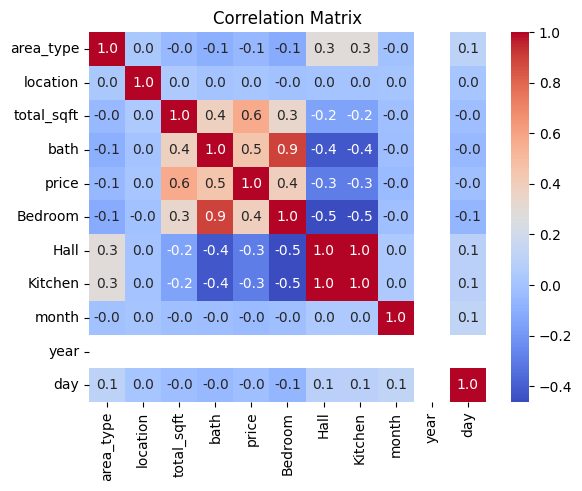

In [ ]:
corr_matrix=df.corr()

sns.heatmap(corr_matrix,annot=True,fmt='0.01f',cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
df.drop(['Bedroom','Kitchen','Hall'],axis=1,inplace=True)

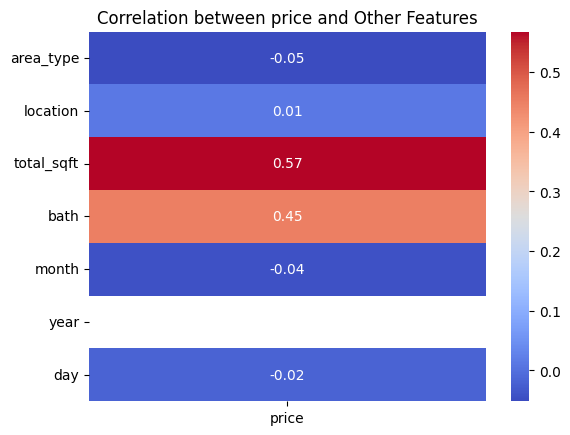

In [ ]:
price_corr= df.corr()['price']

price_corr=price_corr.drop('price')

sns.heatmap(price_corr.to_frame(),annot=True,fmt='.2f',cmap='coolwarm',
            cbar=True,annot_kws={'size':10})
plt.title('Correlation between price and Other Features')
plt.show()

In [ ]:
df.drop(['location','month','day','area_type'],axis=1,inplace=True)

<Axes: >

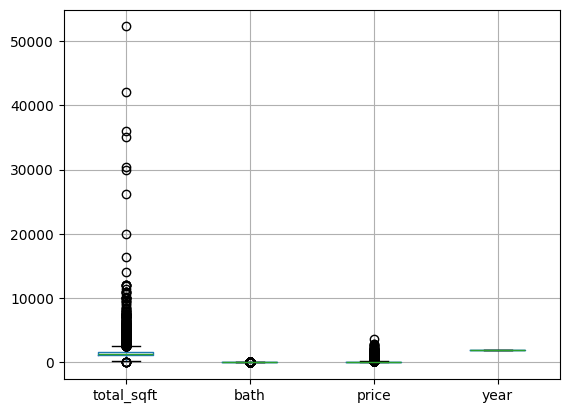

In [ ]:
df.boxplot()

In [ ]:
def remove_outliers_iqr(df,exclude_column):
  for col in df.columns:
    if col == exclude_column:
      continue
    Q1=df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR

    df=df[(df[col]>=lower_bound) & (df[col]<=upper_bound)]
  return df

  df_cleaned= remove_outliers_iqr(df,exclude_column='price')
  df=df_cleaned

In [ ]:
df.shape

(12635, 4)

**Data scaling**

In [ ]:
df

,total_sqft,bath,price,year
0,1056.0,2.0,39.07,1900
1,2600.0,5.0,120.00,1900
2,1440.0,2.0,62.00,1900
3,1521.0,3.0,95.00,1900
4,1200.0,2.0,51.00,1900
...,...,...,...,...
13314,1715.0,3.0,112.00,1900
13315,3453.0,4.0,231.00,1900
13316,3600.0,5.0,400.00,1900
13317,1141.0,2.0,60.00,1900


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

features=['total_sqft','bath','year',]

scaler=MinMaxScaler()

scaled_data=scaler.fit_transform(df[features])

scaled_df= pd.DataFrame(scaled_data,columns=features)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
import pandas as pd

x=df[['total_sqft','bath','year']]
y=df['price']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.50,random_state=32)

model=LinearRegression()
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
accuracy= model.score(x_test,y_test)
print(f'Baseline model accuracy:{accuracy:2f}')

Baseline model accuracy:0.388643
